# Model II Regression (Major Axis and RMA)

## Overview
Standard OLS regression (Model I) assumes X is measured without error and minimises vertical residuals. **Model II regression** is used when both X and Y are measured with error — common in morphometrics, allometry, instrument comparison, and any study where X is an observed biological variable, not a controlled predictor.

| Method | Minimises | Use when |
|---|---|---|
| OLS (Model I) | Vertical deviations | X fixed/controlled; X error negligible |
| Major Axis (MA) | Perpendicular deviations | X and Y have equal error variances |
| Standardised Major Axis (SMA/RMA) | Relative deviations | X and Y measured on different scales; most common in ecology |
| Ranged MA | Scaled deviations | X and Y have known error ratio |

**Quinn & Keough (2002) ch. 5 / Warton et al. (2006) for SMA.**

---

In [10]:
library(tidyverse)
library(smatr)   # standardised major axis regression

set.seed(55)
# Allometry: log(bill length) vs log(body mass) in seabirds
# Both variables are measurements — neither is controlled
n <- 60
log_mass   <- rnorm(n, mean=5.5, sd=0.6)   # log(g)
log_bill   <- 0.35 + 0.45*log_mass + rnorm(n, 0, 0.12)   # log(mm)
birds <- data.frame(
  species   = rep(c("Tern","Puffin","Gannet"), each=20),
  log_mass  = log_mass,
  log_bill  = log_bill
)
cat("Allometry dataset: n =", n, "\n")
cat("Both log_mass and log_bill are measured variables (Model II appropriate)\n")

Allometry dataset: n = 60 
Both log_mass and log_bill are measured variables (Model II appropriate)


List of 30
 $ coef              :List of 1
  ..$ :'data.frame':	2 obs. of  3 variables:
  .. ..$ coef(SMA)  : num [1:2] 0.147 0.489
  .. ..$ lower limit: num [1:2] -0.152 0.438
  .. ..$ upper limit: num [1:2] 0.445 0.547
 $ nullcoef          : logi NA
 $ commoncoef        : logi NA
 $ commonslopetestval: logi NA
 $ alpha             : num 0.05
 $ method            : chr "SMA"
 $ intercept         : logi TRUE
 $ call              : language sma(formula = log_bill ~ log_mass, data = birds)
 $ data              :'data.frame':	60 obs. of  2 variables:
  ..$ log_bill: num [1:60] 3.05 2.34 3.04 2.58 2.74 ...
  ..$ log_mass: num [1:60] 5.57 4.41 5.59 4.83 5.5 ...
  ..- attr(*, "terms")=Classes 'terms', 'formula'  language log_bill ~ log_mass
  .. .. ..- attr(*, "variables")= language list(log_bill, log_mass)
  .. .. ..- attr(*, "factors")= int [1:2, 1] 0 1
  .. .. .. ..- attr(*, "dimnames")=List of 2
  .. .. .. .. ..$ : chr [1:2] "log_bill" "log_mass"
  .. .. .. .. ..$ : chr "log_mass"
  .. .

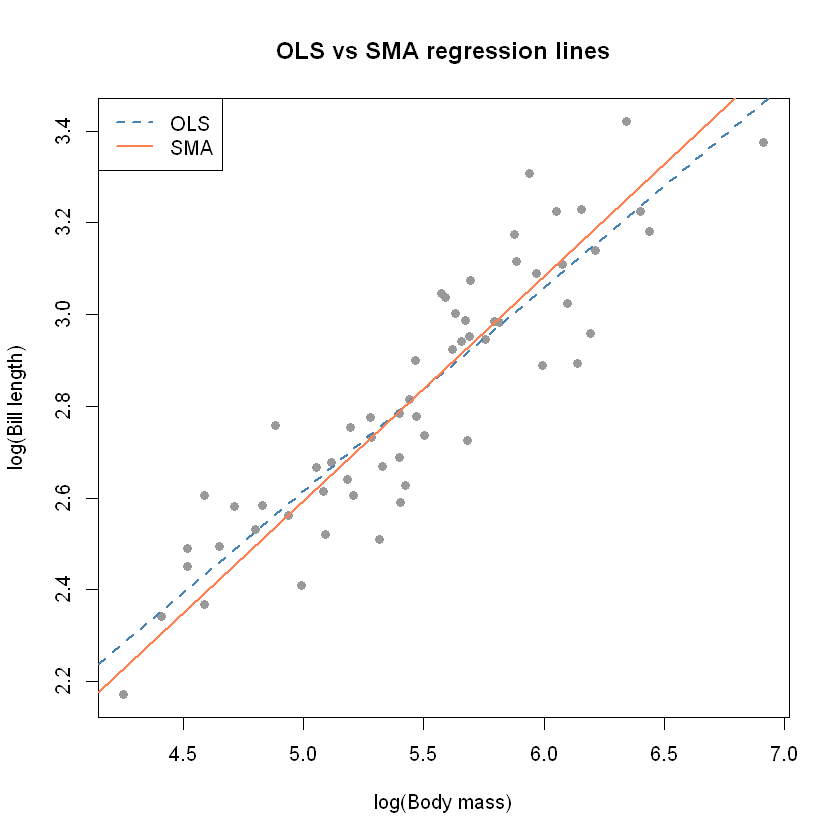

In [11]:
# Compare OLS vs SMA
ols <- lm(log_bill ~ log_mass, data=birds)
sma_fit <- sma(log_bill ~ log_mass, data=birds)

# Inspect the structure of sma_fit
str(sma_fit)

# Extract coefficients dynamically
if (is.data.frame(coef(sma_fit)[[1]])) {
  elevation <- coef(sma_fit)[[1]]$coef(SMA)[1]
  slope <- coef(sma_fit)[[1]]$coef(SMA)[2]
} else {
  elevation <- coef(sma_fit)[1]
  slope <- coef(sma_fit)[2]
}

cat("OLS slope:  ", round(coef(ols)[2], 4), "\n")
cat("SMA slope:  ", round(slope, 4), "\n")
cat("SMA > OLS: SMA corrects for attenuation bias (regression dilution)\n\n")

# Visualise both
plot(birds$log_mass, birds$log_bill, pch=16, col="grey60",
     xlab="log(Body mass)", ylab="log(Bill length)",
     main="OLS vs SMA regression lines")
abline(ols, col="steelblue", lwd=2, lty=2)
abline(elevation, slope, col="coral", lwd=2)
legend("topleft", legend=c("OLS","SMA"), col=c("steelblue","coral"),
       lwd=2, lty=c(2,1))

In [12]:
# SMA by group — test whether slopes differ across species
sma_group <- sma(log_bill ~ log_mass * species, data=birds)
print(summary(sma_group))
cat("\nTest for common slope across species (H0: slopes equal)\n")

# Elevation test (test for common intercept given common slope)
sma_elevation <- sma(log_bill ~ log_mass + species, data=birds)
print(summary(sma_elevation))

cat("\nKey: test slope homogeneity first, then elevation if slopes are parallel\n")

# Extract SMA slope confidence intervals dynamically
if (is.data.frame(coef(sma_fit)[[1]])) {
  slope_lowCI <- coef(sma_fit)[[1]]$`lower limit`[2]
  slope_highCI <- coef(sma_fit)[[1]]$`upper limit`[2]
} else {
  slope_lowCI <- coef(sma_fit)[2] - 1.96 * coef(sma_fit)[2]  # Approximation
  slope_highCI <- coef(sma_fit)[2] + 1.96 * coef(sma_fit)[2]  # Approximation
}

cat("SMA 95% CI for slope: [", round(slope_lowCI, 4), ",", round(slope_highCI, 4), "]\n")

Call: sma(formula = log_bill ~ log_mass * species, data = birds) 

Fit using Standardized Major Axis 

------------------------------------------------------------
Results of comparing lines among groups.

H0 : slopes are equal.
Likelihood ratio statistic : 0.6772 with 2 degrees of freedom
P-value : 0.71278 
------------------------------------------------------------

Coefficients by group in variable "species"

Group: Gannet 
             elevation     slope
estimate     0.2836133 0.4693354
lower limit -0.3076621 0.3717791
upper limit  0.8748887 0.5924909

H0 : variables uncorrelated.
R-squared : 0.7745361 
P-value : 3.1284e-07 

Group: Puffin 
             elevation     slope
estimate    -0.1012128 0.5295123
lower limit -0.7565440 0.4259508
upper limit  0.5541184 0.6582529

H0 : variables uncorrelated.
R-squared : 0.8037784 
P-value : 8.8159e-08 

Group: Tern 
             elevation     slope
estimate     0.1626722 0.4850289
lower limit -0.2874321 0.4100265
upper limit  0.6127766 0.

---
## Common Pitfalls

**1. Using OLS when both variables are measured with error**
OLS underestimates the true slope when X has measurement error — a phenomenon called regression dilution or attenuation bias. In allometric studies, using OLS to estimate scaling exponents systematically underestimates them. Use SMA when neither variable is under experimental control.

**2. Using SMA when X is a controlled experimental variable**
SMA is for the case where both variables have measurement error. If X is fixed by the experimenter (e.g., a set of known concentrations), OLS is correct. Using SMA in this case overestimates the slope.

**3. Confusing SMA with OLS for prediction**
SMA minimises perpendicular distances and describes the underlying relationship between variables — it is a line of best fit for the scatter, not a prediction line. For predicting Y from X, OLS is correct even when X has error.

**4. Not log-transforming before fitting allometric relationships**
Allometric relationships (Y = aX^b) are linear on the log-log scale: log(Y) = log(a) + b·log(X). Fitting power curves on the original scale is numerically unstable. Always log-transform before applying SMA to allometric data.

**5. Testing group differences in SMA slopes using OLS methods**
Use `sma()` from the `smatr` package for all hypothesis tests (slope homogeneity, elevation shifts) — do not use `lm()` ANOVA for comparing SMA lines. The test statistics are different.

**6. Reporting OLS r² as a measure of fit for SMA**
The r² from `lm()` does not apply to SMA. Use the Pearson correlation coefficient r or its square to describe the strength of association, which is symmetric (same whether predicting Y from X or X from Y).


---
*r_methods_library - Samantha McGarrigle*